In [1]:
#imports
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib as mpl
from matplotlib.lines import Line2D

In [2]:
#fixing figure size
#plt.rcParams["figure.figsize"] = (8, 8) # Sets the default figure size to 8x8 inches

In [2]:
#setting palette
palette = sns.color_palette('colorblind')
sns.set_palette('colorblind')
cmap = plt.cm.coolwarm

<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_218741/2602333052.py:5: SyntaxWarning: invalid escape sequence '\O'
  plt.ylabel('$\Omega_c~/~\Omega_0$')


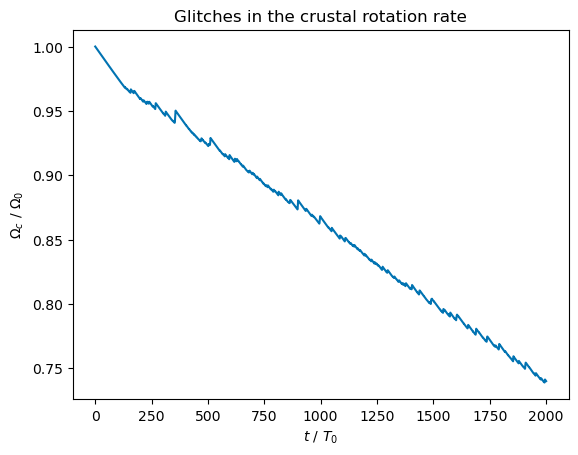

In [4]:
#plotting glitches
data = pd.read_csv(r'/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/setB/run1/sim_omega_c.dat', delimiter='\t')
plt.plot(data['t/T_0'],data['omega_c/omega_0'])
plt.xlabel('$t~/~T_0$')
plt.ylabel('$\Omega_c~/~\Omega_0$')
plt.title('Glitches in the crustal rotation rate')
#plt.savefig('/home/thirdparty/ananth/superspin/temp/plots/20260401/fullglitches/setB/fullglitches_setB.png', dpi=300, bbox_inches='tight')
plt.show()

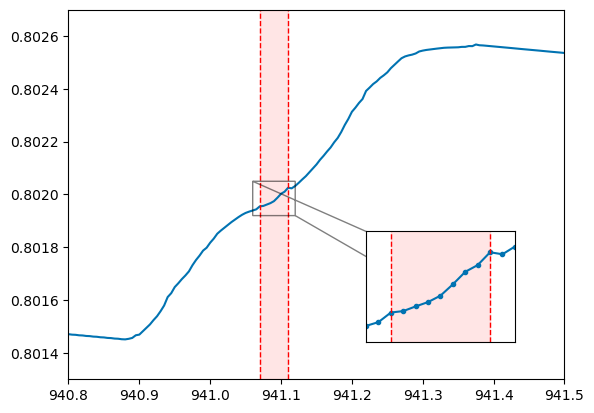

In [18]:
#plotting glitch with zoomed inset
data = pd.read_csv(r'/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/set0/run1/sim_omega_c.dat', delimiter='\t')
fig, ax = plt.subplots()
ax.plot(data['t/T_0'],data['omega_c/omega_0'])
ax.set_xlim(940.8, 941.5)
ax.set_ylim(0.8013,0.8027)
ax.axvline(x=941.07, color='red', linestyle='--', linewidth=1)
ax.axvline(x=941.11, color='red', linestyle='--', linewidth=1)
ax.axvspan(xmin=941.07, xmax=941.11, color='red', alpha=0.1)

# Add inset axes [x, y, width, height]
axins = ax.inset_axes([0.6, 0.1, 0.3, 0.3], xticklabels=[], yticklabels=[])
axins.plot(data['t/T_0'],data['omega_c/omega_0'], marker='o', markersize=3)

# Set zoom window (the "zoom" part)
x1, x2, y1, y2 = 941.06, 941.12, 0.80192, 0.80205
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.axvline(x=941.07, color='red', linestyle='--', linewidth=1)
axins.axvline(x=941.11, color='red', linestyle='--', linewidth=1)
axins.axvspan(xmin=941.07, xmax=941.11, color='red', alpha=0.1)
axins.tick_params(axis='both', length=0)

# Add zoom indicators (lines/box)
ax.indicate_inset_zoom(axins, edgecolor="black")

#plt.savefig(r"/home/thirdparty/ananth/superspin/saves/plots/20260401/trapwise_10traps.png", dpi=300, bbox_inches='tight')
plt.show()

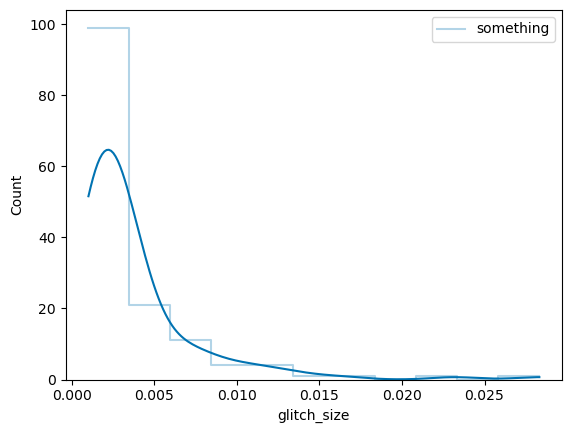

In [7]:
#plot distribution

cutoff = 1e-3

data = pd.read_csv('/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/set0/data_glitch_multi.dat', delimiter = '\t')
data = data[data['glitch_size']>cutoff]

nbin = int(np.sqrt(len(data)))
sns.histplot(data['glitch_size'], label = 'something', bins = nbin, kde=True, fill=False,alpha = 0.3,stat='count',element='step')
plt.legend()
plt.show()

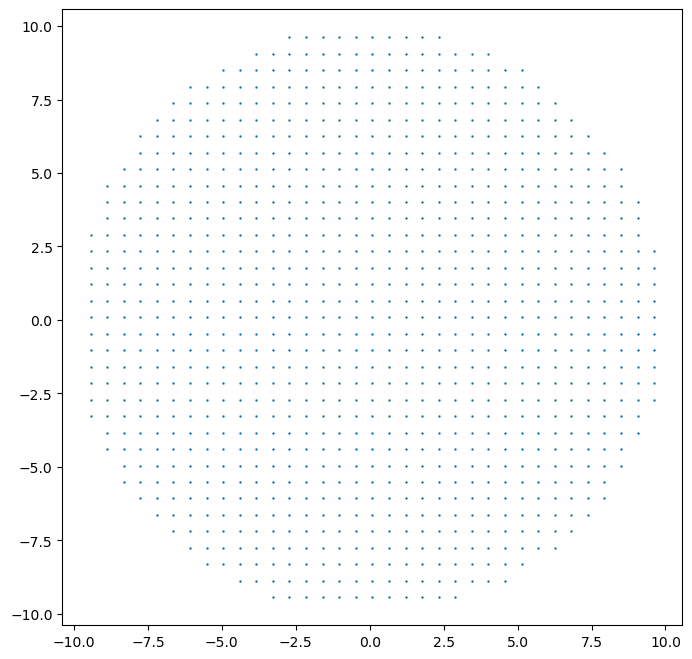

In [11]:
#plot pinning sites

#data = np.loadtxt('/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/setA/run1/sim_vortex_pos.dat', delimiter='\t', skiprows=1+(t_interest*resolution), max_rows=1)
data = pd.read_csv('/home/thirdparty/ananth/superspin/output/run1/init_pins_pos.dat', delimiter='\t')

fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(data['x'],data['y'],s=0.5)
#plt.xlim(-1,+1)
#plt.ylim(-1,+1)
plt.show()

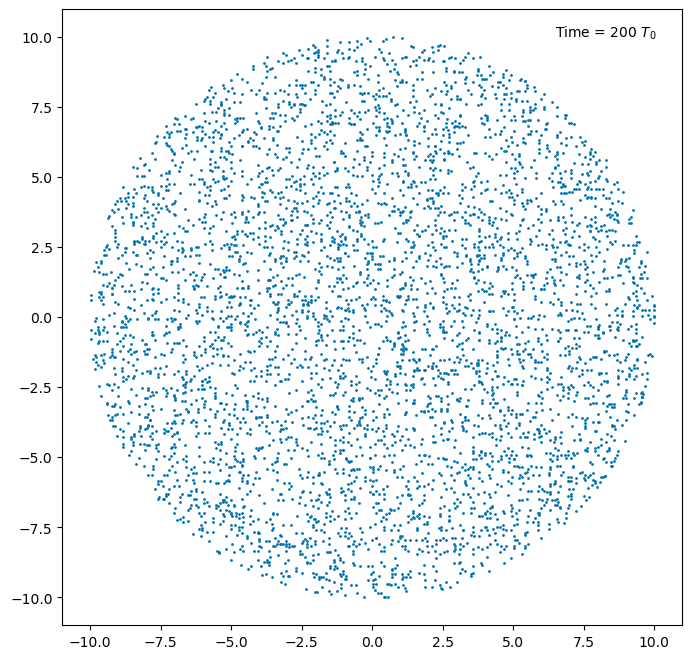

In [8]:
#plot vortex positions - single time slice

n_vortices = 5000
resolution = 20 #number of datapoints per T_0
t_interest = 200

data = np.loadtxt('/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/setA/run1/sim_vortex_pos.dat', delimiter='\t', skiprows=1+(t_interest*resolution), max_rows=1)
data_t = data[0]
data_x = data[1:n_vortices+1]
data_y = data[n_vortices+1:(2*n_vortices)+1]

fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(data_x,data_y,s=1)
ax.text(6.5,10,f'Time = {t_interest} $T_0$')
plt.show()

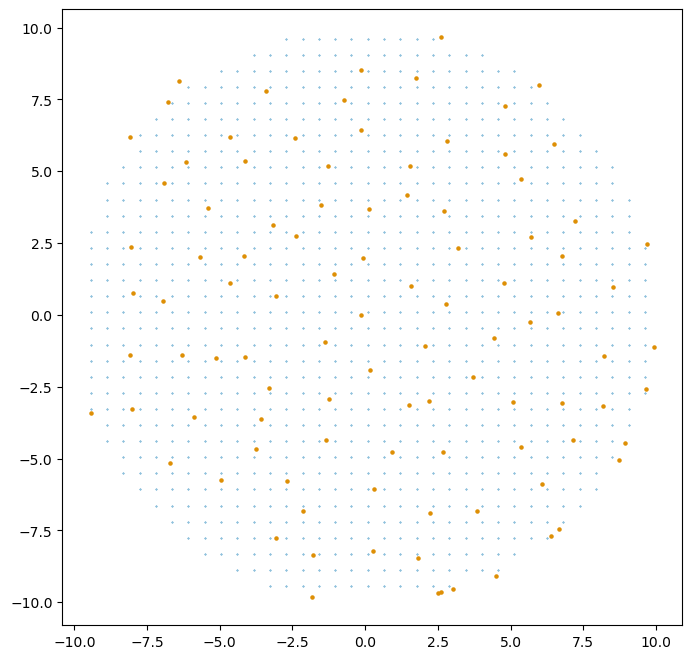

In [15]:
#plot pinning sites and vortices

#data = np.loadtxt('/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/setA/run1/sim_vortex_pos.dat', delimiter='\t', skiprows=1+(t_interest*resolution), max_rows=1)
data_sites = pd.read_csv('/home/thirdparty/ananth/superspin/output/run1/init_pins_pos.dat', delimiter='\t')
data_vortices = pd.read_csv('/home/thirdparty/ananth/superspin/output/run1/stabilized_vortex_pos.dat', delimiter='\t')

fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(data_sites['x'],data_sites['y'],s=0.1)
ax.scatter(data_vortices['x'],data_vortices['y'],s=5)
#plt.xlim(-1,+1)
#plt.ylim(-1,+1)
plt.show()

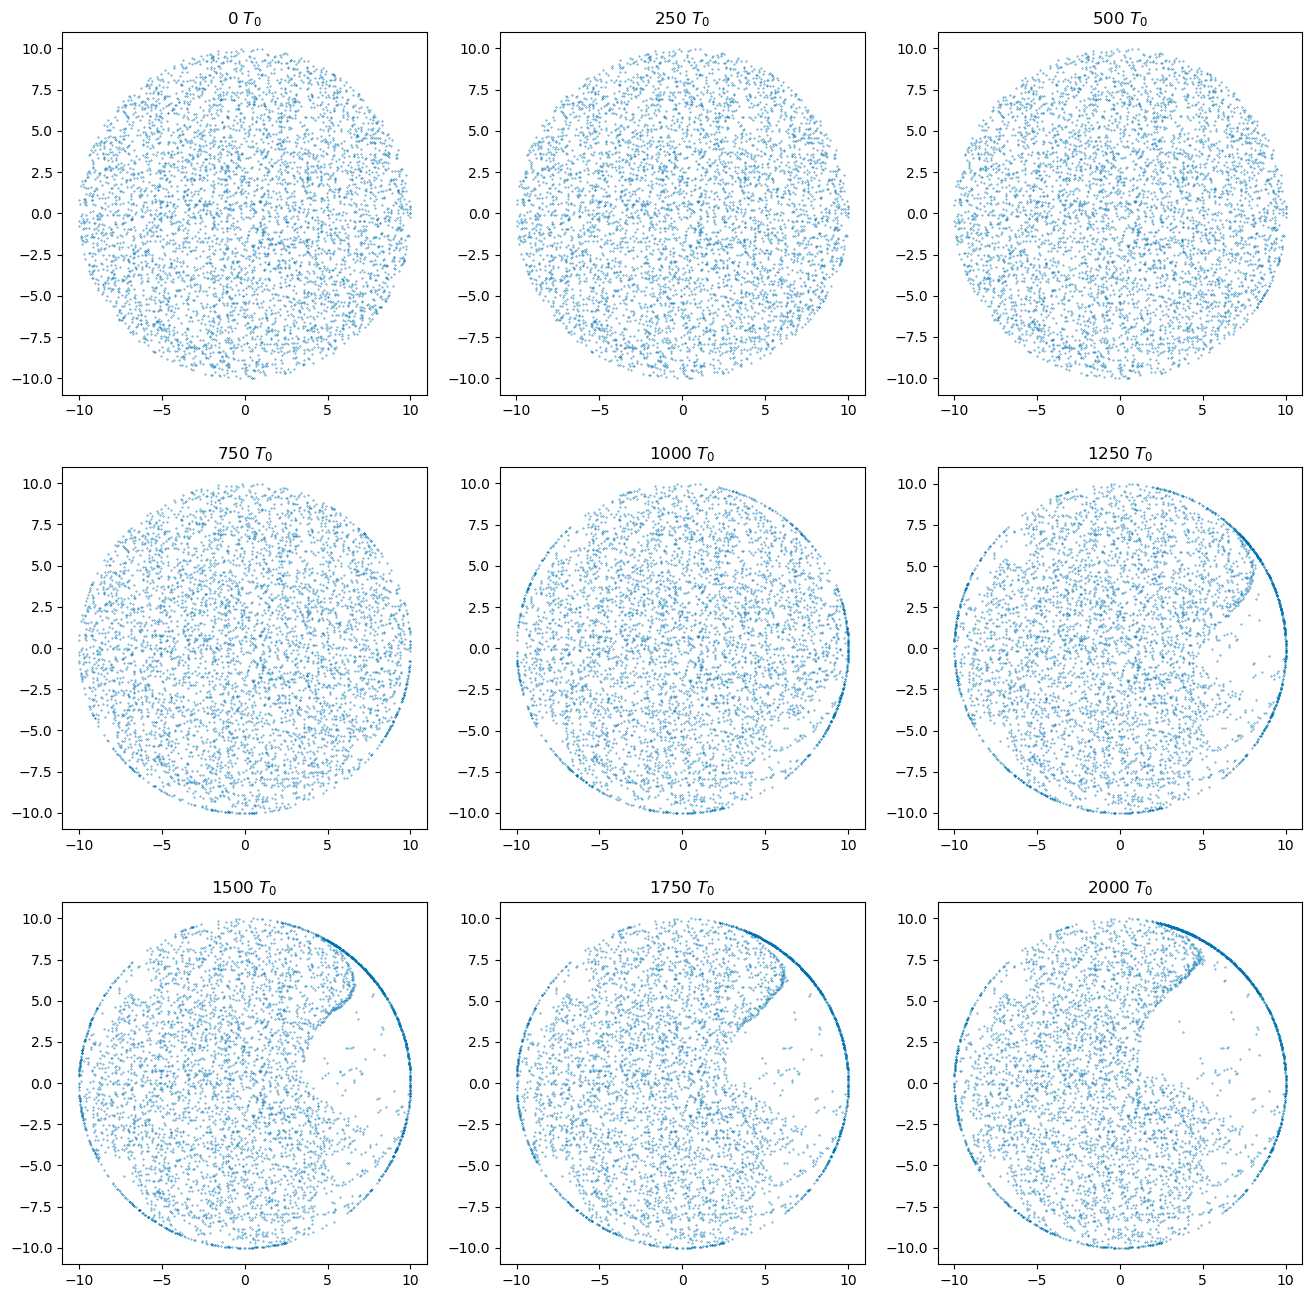

In [19]:
#plot vortex positions - multiple time slices

n_vortices = 5000
resolution = 20 #number of datapoints per T_0
t_interest = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]

fig, axs = plt.subplots(3,3,figsize=(16,16))
axs = axs.flatten()
index = 0

for t in t_interest:
    data = np.loadtxt('/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/setA/run1/sim_vortex_pos.dat', delimiter='\t', skiprows=1+(t_interest[index]*resolution), max_rows=1)
    data_t = data[0]
    data_x = data[1:n_vortices+1]
    data_y = data[n_vortices+1:(2*n_vortices)+1]
    axs[index].scatter(data_x,data_y,s=0.1)
    axs[index].set_title(f'{t_interest[index]} $T_0$')
    index = index + 1
#plt.savefig(f"/home/thirdparty/ananth/superspin/saves/plots/20260401/arrayevolution/setA/evolution.png", dpi=300, bbox_inches='tight')
plt.show()

<>:119: SyntaxWarning: invalid escape sequence '\O'
<>:119: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_111906/3361743124.py:119: SyntaxWarning: invalid escape sequence '\O'
  axs[2*index+1].set_title('Spin evolution ($t/T_0$ vs $\Omega_c/\Omega_0$)')


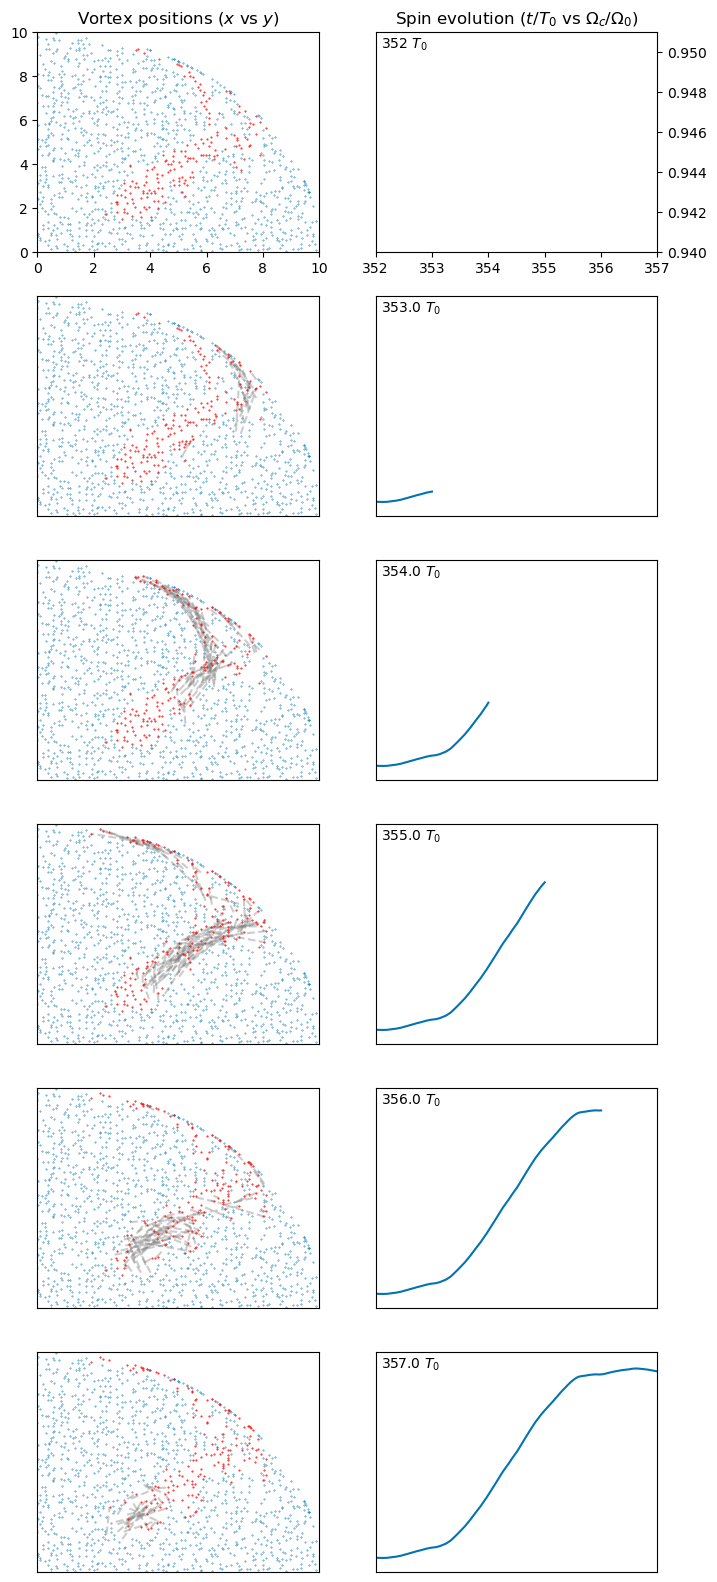

In [20]:
#plot evolution of vortex array during glitch
#vortex movement at a given time slice and the corresponding glitch progress
#a few such time slices arranged chronologically
#change the xlim and ylim as needed for the rotation rate

#timeframe of interest
resolution = 20 #number of datapoints per T_0
t_start = 352 #start time of glitch
t_end = 357 #end time of glitch
number_of_slices = 5

#parameters of the system required to find moving vortices
n_vortices = 5000
a = 0.056 # Lattice spacing of pinning sites
epsilon = a # A vortex is considered to have moved in the chosen slice of time if its displacement is greater than epsilon

#create times of interest
t_interest = []
t_current = t_start
while(t_current <= t_end):
    t_interest.append(t_current)
    t_current = t_current + (t_end-t_start)/number_of_slices

#position of vortices at the start and at the end of the glitch
data_array_start = np.loadtxt('/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/setB/run1/sim_vortex_pos.dat', delimiter='\t', skiprows=1+int(t_interest[0]*resolution), max_rows=1)
data_array_start_x = data_array_start[1:n_vortices+1]
data_array_start_y = data_array_start[n_vortices+1:(2*n_vortices)+1]

data_array_end = np.loadtxt('/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/setB/run1/sim_vortex_pos.dat', delimiter='\t', skiprows=1+int(t_interest[-1]*resolution), max_rows=1)
data_array_end_x = data_array_end[1:n_vortices+1]
data_array_end_y = data_array_end[n_vortices+1:(2*n_vortices)+1]

#finding index of moving vortices
index_moving=[]
index_fixed=[]
for i in range(0,n_vortices,1):
    delta_r = np.sqrt((data_array_end_x[i]-data_array_start_x[i])**2 + (data_array_end_y[i]-data_array_start_y[i])**2)
    if(delta_r > epsilon):
        index_moving.append(i)
    else:
        index_fixed.append(i)

#plot the time slices
fig, axs = plt.subplots(len(t_interest),2,figsize=(8,4*number_of_slices))
axs = axs.flatten()

for index in range(len(t_interest)):
    #read vortex positions for the appropriate time slice
    data_array = np.loadtxt('/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/setB/run1/sim_vortex_pos.dat', delimiter='\t', skiprows=1+int(t_interest[index]*resolution), max_rows=1)
    data_array_x = data_array[1:n_vortices+1]
    data_array_y = data_array[n_vortices+1:(2*n_vortices)+1]
    
    #scatter plot the fixed vortices
    data_array_fixed_x = []
    data_array_fixed_y = []
    
    for i in index_fixed:
        data_array_fixed_x.append(data_array_x[i])
        data_array_fixed_y.append(data_array_y[i])
    
    axs[2*index].scatter(data_array_fixed_x,data_array_fixed_y,marker = 'o', s=0.1)
    
    #scatter plot the moving vortices
    data_array_moving_x = []
    data_array_moving_y = []
    
    for i in index_moving:
        data_array_moving_x.append(data_array_x[i])
        data_array_moving_y.append(data_array_y[i])
    
    axs[2*index].scatter(data_array_moving_x,data_array_moving_y,marker = 'o',color='red',s=0.2, zorder=3)
    
    #plot tails if index is not zero
    if (index !=0):
        #previous positions of moving vortices
        data_array_previous = np.loadtxt('/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/setB/run1/sim_vortex_pos.dat', delimiter='\t', skiprows=1+int(t_interest[index-1]*resolution), max_rows=1)
        data_array_previous_x = data_array_previous[1:n_vortices+1]
        data_array_previous_y = data_array_previous[n_vortices+1:(2*n_vortices)+1]
        data_array_previous_moving_x = []
        data_array_previous_moving_y = []
        for i in index_moving:
            data_array_previous_moving_x.append(data_array_previous_x[i])
            data_array_previous_moving_y.append(data_array_previous_y[i])
        #plot tails
        for i in range(len(index_moving)):
            tail_x = [data_array_previous_moving_x[i], data_array_moving_x[i]]
            tail_y = [data_array_previous_moving_y[i], data_array_moving_y[i]]
            axs[2*index].plot(tail_x, tail_y, linestyle = '--', color ='grey', alpha = 0.4, zorder=2)
    
    #set limits
    axs[2*index].set_xlim(0,10)
    axs[2*index].set_ylim(0,10)
    #set ticks
    #default if index = 0 and tick off otherwise
    if (index != 0):
        axs[2*index].set_xticks([])
        axs[2*index].set_yticks([])
    #set title
    if (index == 0):
        axs[2*index].set_title('Vortex positions ($x$ vs $y$)')
    
    #plot the rotation rate
    data_rot = pd.read_csv(r'/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/setB/run1/sim_omega_c.dat', delimiter='\t')
    data_rot = data_rot[data_rot['t/T_0'] < t_interest[index]]
    axs[2*index+1].plot(data_rot['t/T_0'],data_rot['omega_c/omega_0'])
    axs[2*index+1].set_xlim(t_start,t_end)
    axs[2*index+1].set_ylim(0.9400,0.9510)
    #set time text
    axs[2*index+1].text(352.1,0.9502,f'{t_interest[index]} $T_0$')
    #set ticks
    #yaxis to right if index = 0 and tick off otherwise
    if (index == 0):
        axs[2*index+1].yaxis.tick_right()
    else:
        axs[2*index+1].set_xticks([])
        axs[2*index+1].set_yticks([])
    #set title
    if (index == 0):
        axs[2*index+1].set_title('Spin evolution ($t/T_0$ vs $\Omega_c/\Omega_0$)')
    
#plt.savefig(f"/home/thirdparty/ananth/superspin/saves/plots/20260401/glitchevolution/setB/glitchevolution.png", dpi=300, bbox_inches='tight')
plt.show()

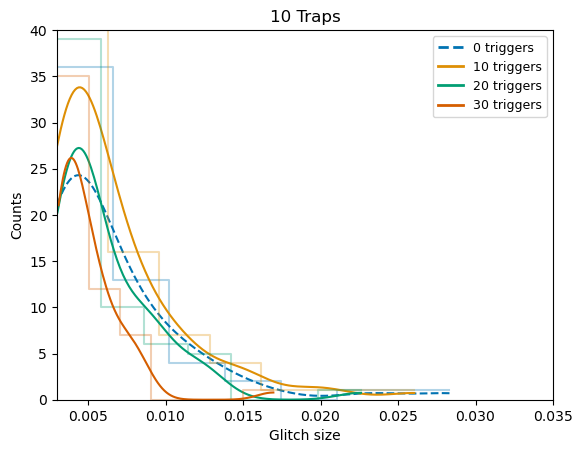

In [24]:
# Plot distributions

cutoff = 3e-3

# 0 triggers
data0 = pd.read_csv('/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/set0/data_glitch_multi.dat', delimiter = '\t')
data0 = data0['glitch_size']
data0 = data0[data0>cutoff]
logdata0 = np.log10(data0)

# 20 triggers, 1 traps
data1 = pd.read_csv('/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/set1/data_glitch_multi.dat', delimiter = '\t')
data1 = data1['glitch_size']
data1 = data1[data1>cutoff]
logdata1 = np.log10(data1)

# 10 triggers, 1 traps
data2 = pd.read_csv('/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/set2/data_glitch_multi.dat', delimiter = '\t')
data2 = data2['glitch_size']
data2 = data2[data2>cutoff]
logdata2 = np.log10(data2)

# 30 triggers, 1 traps
data3 = pd.read_csv('/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/set3/data_glitch_multi.dat', delimiter = '\t')
data3 = data3['glitch_size']
data3 = data3[data3>cutoff]
logdata3 = np.log10(data3)

# 20 triggers, 5 traps
data4 = pd.read_csv('/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/set4/data_glitch_multi.dat', delimiter = '\t')
data4 = data4['glitch_size']
data4 = data4[data4>cutoff]
logdata4 = np.log10(data4)

# 20 triggers, 10 traps
data5 = pd.read_csv('/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/set5/data_glitch_multi.dat', delimiter = '\t')
data5 = data5['glitch_size']
data5 = data5[data5>cutoff]
logdata5 = np.log10(data5)

# 30 triggers, 5 traps
data6 = pd.read_csv('/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/set6/data_glitch_multi.dat', delimiter = '\t')
data6 = data6['glitch_size']
data6 = data6[data6>cutoff]
logdata6 = np.log10(data6)

# 30 triggers, 10 traps
data7 = pd.read_csv('/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/set7/data_glitch_multi.dat', delimiter = '\t')
data7 = data7['glitch_size']
data7 = data7[data7>cutoff]
logdata7 = np.log10(data7)

# 10 triggers, 5 traps
data8 = pd.read_csv('/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/set8/data_glitch_multi.dat', delimiter = '\t')
data8 = data8['glitch_size']
data8 = data8[data8>cutoff]
logdata8 = np.log10(data8)

# 10 triggers, 10 traps
data9 = pd.read_csv('/mnt/usb-Realtek_RTL9210_NVME_012345679989-0:0-part2/backup_work/vortex/runs/20260401/set9/data_glitch_multi.dat', delimiter = '\t')
data9 = data9['glitch_size']
data9 = data9[data9>cutoff]
logdata9 = np.log10(data9)

nbin = int(np.sqrt(len(data0)))
wbin = 0.001

sns.histplot(data0, bins = nbin, label='0 triggers',kde=True, fill=False,alpha = 0.3,stat='count',element='step', multiple='dodge', line_kws={'ls':'--'})
#sns.histplot(data2, bins = nbin, label='10 triggers, 1 trap',kde=True, fill=False,alpha = 0.3,stat='count',element='step', multiple='dodge')
#sns.histplot(data1, bins = nbin, label='20 triggers, 1 trap',kde=True, fill=False,alpha = 0.3,stat='count',element='step', multiple='dodge')
#sns.histplot(data3, bins = nbin, label='30 triggers, 1 trap',kde=True, fill=False,alpha = 0.3,stat='count',element='step', multiple='dodge')
#sns.histplot(data8, bins = nbin, label='10 triggers, 5 traps',kde=True, fill=False,alpha = 0.3,stat='count',element='step', multiple='dodge')
#sns.histplot(data4, bins = nbin, label='20 triggers, 5 traps',kde=True, fill=False,alpha = 0.3,stat='count',element='step', multiple='dodge')
#sns.histplot(data6, bins = nbin, label='30 triggers, 5 traps',kde=True, fill=False,alpha = 0.3,stat='count',element='step', multiple='dodge')
sns.histplot(data9, bins = nbin, label='10 triggers, 10 traps',kde=True, fill=False,alpha = 0.3,stat='count',element='step', multiple='dodge')
sns.histplot(data5, bins = nbin, label='20 triggers, 10 traps',kde=True, fill=False,alpha = 0.3,stat='count',element='step', multiple='dodge')
sns.histplot(data7, bins = nbin, label='30 triggers, 10 traps',kde=True, fill=False,alpha = 0.3,stat='count',element='step', multiple='dodge')

custom_lines = [Line2D([0], [0], color=palette[0], lw=2, linestyle ='--'),
                Line2D([0], [0], color=palette[1], lw=2),
                Line2D([0], [0], color=palette[2], lw=2),
               Line2D([0], [0], color=palette[3], lw=2),]
plt.legend(custom_lines,['0 triggers','10 triggers','20 triggers','30 triggers'],prop={'size': 9})

plt.xlabel('Glitch size')
plt.ylabel('Counts')
plt.title('10 Traps')
plt.xlim(0.003, 0.035)
plt.ylim(0, 40)
#plt.savefig(r"/home/thirdparty/ananth/superspin/saves/plots/20260401/trapwise_10traps.png", dpi=300, bbox_inches='tight')
plt.show()